# Diagnóstico del resultado de Adaptive Hyperparam Search
Este notebook carga la carpeta del modelo generada por `adaptive_hyperparam_search.py` y genera gráficas: evolución de trials, métricas por fold, residuales en holdout, importancia de features y leaderboard.

Instrucciones: ajusta la variable `MODEL_DIR` en la siguiente celda al folder donde están los artefactos (_best.joblib, _history.json, leaderboard, _report.md).

In [34]:
# Parámetros: establece aquí la carpeta del modelo
MODEL_DIR = "/users/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/models/extra_trees/all-devices-no-imu"  # <- ajusta esta ruta a la carpeta del modelo
# Si tu carpeta tiene un prefijo específico, puedes setear PREFIX = 'mi_prefijo'
PREFIX = None

In [35]:
# Imports
import json
import os
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")

In [36]:
def load_artifacts(model_dir):
    p = Path(model_dir)
    out = {}
    # model (pick * _best.joblib)
    models = list(p.glob('*_best.joblib'))
    out['model_path'] = models[0] if models else None
    out['model'] = joblib.load(out['model_path']) if out['model_path'] else None
    # history json
    history_files = list(p.glob('*_history.json'))
    out['history_path'] = history_files[0] if history_files else None
    if out['history_path']:
        with open(out['history_path'], 'r') as fh:
            try:
                out['history'] = json.load(fh)
            except Exception:
                out['history'] = None
    else:
        out['history'] = None
    # leaderboard
    lb_csv = list(p.glob('*leaderboard*.csv'))
    out['leaderboard_path'] = lb_csv[0] if lb_csv else None
    out['leaderboard'] = pd.read_csv(out['leaderboard_path'], low_memory=False) if out['leaderboard_path'] else None
    # report md
    md = list(p.glob('*_report.md'))
    out['report_path'] = md[0] if md else None
    out['report'] = out['report_path'].read_text() if out['report_path'] else None
    return out

In [37]:
def try_load_holdout_df(model_dir):
    p = Path(model_dir)

    # 1) nombres exactos comunes
    for name in ['holdout_predictions.csv', 'holdout_frame.csv', 'holdout_preds.csv']:
        f = p / name
        if f.exists():
            try:
                return pd.read_csv(f, low_memory=False)
            except Exception:
                pass

    # 2) nombres con prefijo (ej: <prefix>_<model>_holdout_predictions.csv)
    prefixed_candidates = sorted(p.glob('*_holdout_predictions.csv')) + sorted(p.glob('*holdout*pred*.csv'))
    for f in prefixed_candidates:
        if f.exists():
            try:
                return pd.read_csv(f, low_memory=False)
            except Exception:
                pass

    return None

In [38]:
# Carga artefactos
art = load_artifacts(MODEL_DIR)
print('model_path:', art['model_path'])
print('history_path:', art['history_path'])
print('leaderboard_path:', art['leaderboard_path'])
print('report_path:', art['report_path'])

model_path: /users/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/models/extra_trees/all-devices-no-imu/all-devices-no-imu_extra_trees_best.joblib
history_path: /users/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/models/extra_trees/all-devices-no-imu/all-devices-no-imu_extra_trees_history.json
leaderboard_path: /users/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/models/extra_trees/all-devices-no-imu/all-devices-no-imu_extra_trees_leaderboard.csv
report_path: None


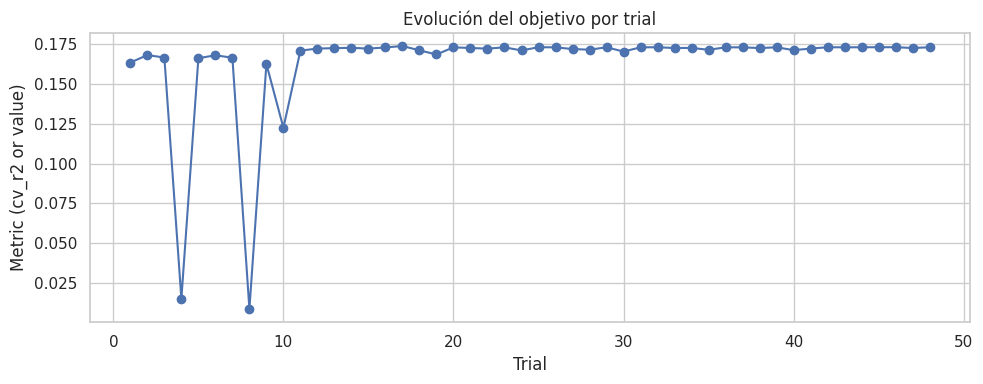

In [39]:
# 1) Evolución de trials (objetivo)
history = art.get('history')
trials = []
if history is None:
    # maybe history file contains a list directly
    print('No hay history.json cargado.')
else:
    # history may be {'history': [...], 'training_context': {...}}
    if isinstance(history, dict) and 'history' in history:
        trials = history['history']
    elif isinstance(history, list):
        trials = history
    else:
        trials = []

# extraer métrica por trial (try several keys)
vals = []
for i, t in enumerate(trials):
    # t may be a dict representation of TrialResult
    v = None
    # try cv_fold_r2s -> mean
    if isinstance(t, dict):
        if 'cv_fold_r2s' in t and t['cv_fold_r2s']:
            try:
                v = float(np.mean(t['cv_fold_r2s']))
            except Exception:
                v = None
        elif 'cv_r2' in t:
            v = float(t.get('cv_r2'))
        elif 'value' in t:
            v = float(t.get('value'))
        elif 'trial_value' in t:
            v = float(t.get('trial_value'))
    vals.append((i+1, v))

if any(v is not None for (_, v) in vals):
    xs = [x for x, v in vals if v is not None]
    ys = [v for x, v in vals if v is not None]
    plt.figure(figsize=(10,4))
    plt.plot(xs, ys, marker='o')
    plt.xlabel('Trial')
    plt.ylabel('Metric (cv_r2 or value)')
    plt.title('Evolución del objetivo por trial')
    plt.tight_layout()
    plt.show()
else:
    print('No se pudo extraer una métrica por trial desde history.json.')

### Qué significa esta gráfica
Esta curva muestra cómo cambia la métrica objetivo a medida que avanzan los trials de búsqueda de hiperparámetros.
Si la línea sube y luego se estabiliza, la búsqueda está convergiendo; si oscila mucho, todavía hay espacio para explorar mejores configuraciones.
La interpretación principal es comparar la tendencia general, no solo el mejor punto aislado.

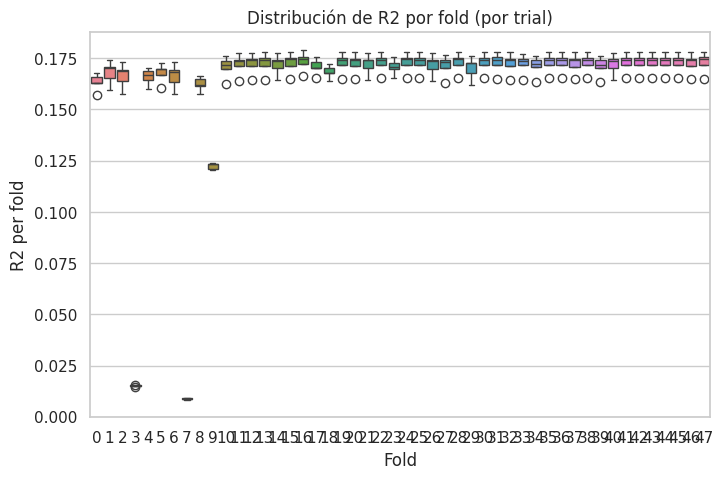

In [40]:
# 2) Distribución por fold (boxplot) si hay cv_fold_r2s
all_fold_vals = []
for t in trials:
    if isinstance(t, dict) and 'cv_fold_r2s' in t and t['cv_fold_r2s']:
        all_fold_vals.append(t['cv_fold_r2s'])

if all_fold_vals:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=all_fold_vals)
    plt.xlabel('Fold')
    plt.ylabel('R2 per fold')
    plt.title('Distribución de R2 por fold (por trial)')
    plt.show()
else:
    print('No hay cv_fold_r2s en los trials para mostrar boxplot.')

### Qué significa esta gráfica
El boxplot resume la variabilidad del R2 entre folds de validación para cada trial.
Cajas estrechas indican un modelo más estable; cajas anchas o con muchos atípicos indican que el rendimiento depende mucho del fold.
Idealmente quieres un R2 alto y una dispersión pequeña entre folds.

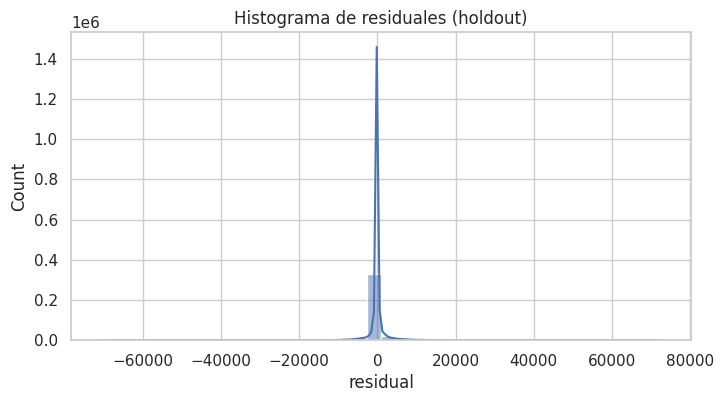

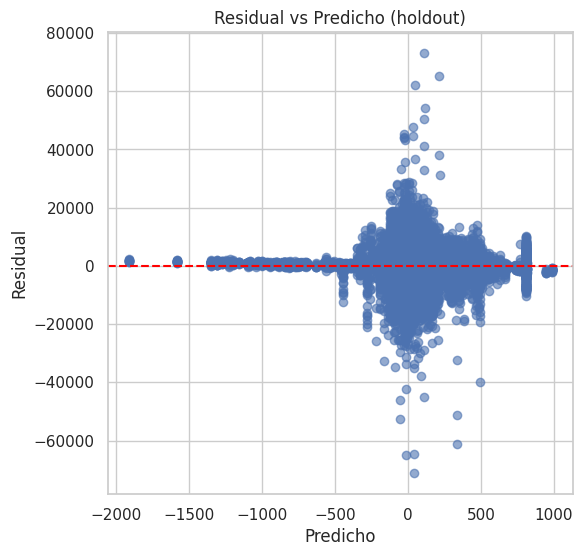

In [41]:
# 3) Holdout residuals (si hay archivo de holdout), sino usar estadísticas resumidas desde history
holdout_df = try_load_holdout_df(MODEL_DIR)
if holdout_df is not None:
    if 'y_true' in holdout_df.columns and 'y_pred' in holdout_df.columns:
        holdout_df['residual'] = holdout_df['y_true'] - holdout_df['y_pred']
        plt.figure(figsize=(8,4))
        sns.histplot(holdout_df['residual'], bins=40, kde=True)
        plt.title('Histograma de residuales (holdout)')
        plt.show()
        plt.figure(figsize=(6,6))
        plt.scatter(holdout_df['y_pred'], holdout_df['residual'], alpha=0.6)
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel('Predicho')
        plt.ylabel('Residual')
        plt.title('Residual vs Predicho (holdout)')
        plt.show()
    else:
        print('holdout_df cargado pero no tiene columnas y_true/y_pred')
else:
    # busca estadísticas en el último trial (best)
    if trials and isinstance(trials[-1], dict):
        last = trials[-1]
        keys = [k for k in ['holdout_residual_mean','holdout_residual_std','holdout_residual_abs_mean'] if k in last]
        if keys:
            print('Estadísticas holdout (desde history, último trial):')
            for k in keys:
                print(f"{k}: {last[k]}")
        else:
            print('No hay holdout detalledo; considera ejecutar adaptive_hyperparam_search configurado para guardar holdout_predictions.csv')
    else:
        print('No hay trials en history para leer estadísticas de holdout.')

### Qué significa esta sección
El histograma de residuales muestra si el modelo se equivoca de forma centrada en cero o si tiene sesgo sistemático.
El gráfico residual vs predicho ayuda a detectar heterocedasticidad, patrones no lineales o zonas donde el modelo se equivoca más.
Si los residuales están centrados en 0 y sin estructura visible, el ajuste es más consistente.

,metric,value
0,rmse,2009.578702
1,mae,755.259941
2,medae,142.369145
3,r2,-0.001306
4,mape_percent,98797.212105
5,bias_mean_error,42.496548
6,p90_abs_error,1981.632395
7,p95_abs_error,4115.004139
8,max_abs_error,73065.159246
9,n_samples,375225.000000


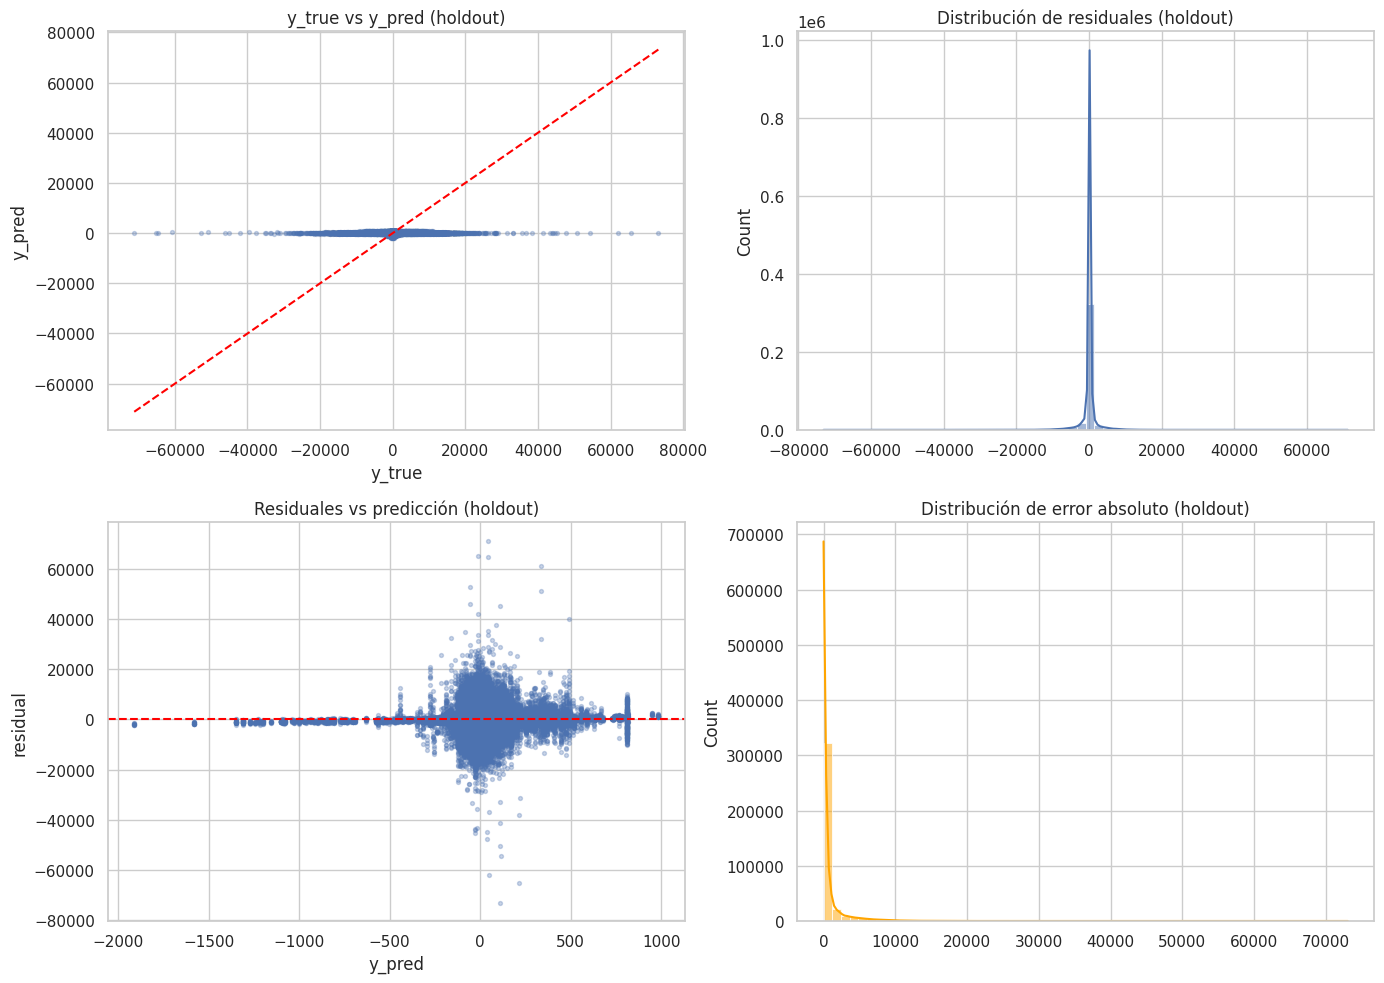

In [42]:
# 3.1) Métricas globales + gráficas base de diagnóstico (holdout)
def safe_mape(y_t, y_p, eps=1e-6):
    denom = np.maximum(np.abs(y_t), eps)
    return float(np.mean(np.abs(y_t - y_p) / denom) * 100.0)


def regression_metrics(y_t, y_p):
    residuals = y_p - y_t
    abs_err = np.abs(residuals)
    metrics = {
        'rmse': float(np.sqrt(mean_squared_error(y_t, y_p))),
        'mae': float(mean_absolute_error(y_t, y_p)),
        'medae': float(median_absolute_error(y_t, y_p)),
        'r2': float(r2_score(y_t, y_p)),
        'mape_percent': safe_mape(y_t, y_p),
        'bias_mean_error': float(np.mean(residuals)),
        'p90_abs_error': float(np.percentile(abs_err, 90)),
        'p95_abs_error': float(np.percentile(abs_err, 95)),
        'max_abs_error': float(np.max(abs_err)),
        'n_samples': int(len(y_t)),
    }
    return pd.DataFrame({'metric': list(metrics.keys()), 'value': list(metrics.values())})


hold = try_load_holdout_df(MODEL_DIR)
if hold is not None and 'y_true' in hold.columns and 'y_pred' in hold.columns:
    y_true = hold['y_true']
    y_pred = hold['y_pred']
    metrics_df = regression_metrics(y_true, y_pred)
    display(metrics_df)

    residuals = y_pred - y_true
    abs_error = residuals.abs()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].scatter(y_true, y_pred, s=8, alpha=0.3)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    axes[0, 0].plot([mn, mx], [mn, mx], color='red', linestyle='--')
    axes[0, 0].set_title('y_true vs y_pred (holdout)')
    axes[0, 0].set_xlabel('y_true')
    axes[0, 0].set_ylabel('y_pred')

    sns.histplot(residuals, bins=60, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Distribución de residuales (holdout)')

    axes[1, 0].scatter(y_pred, residuals, s=8, alpha=0.3)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_title('Residuales vs predicción (holdout)')
    axes[1, 0].set_xlabel('y_pred')
    axes[1, 0].set_ylabel('residual')

    sns.histplot(abs_error, bins=60, kde=True, ax=axes[1, 1], color='orange')
    axes[1, 1].set_title('Distribución de error absoluto (holdout)')

    plt.tight_layout()
    plt.show()
else:
    print('No hay holdout_predictions.csv con y_true/y_pred para calcular métricas y gráficas base.')

### Cómo leer las métricas
`rmse` penaliza más los errores grandes, así que sube cuando hay fallos severos.
`mae` resume el error promedio absoluto y es más fácil de interpretar en la misma escala del target.
`medae` es robusta a outliers y te dice cómo se comporta el caso típico.
`r2` mide cuánto explica el modelo la variabilidad del target: cuanto más cerca de 1, mejor.
`mape_percent` expresa error relativo; es útil, pero puede volverse inestable si el target se acerca a cero.
`bias_mean_error` indica sesgo: positivo significa sobreestimación promedio, negativo subestimación.
`p90_abs_error` y `p95_abs_error` muestran el comportamiento en la cola alta del error.
`max_abs_error` te dice el peor caso observado y sirve para detectar riesgos operativos extremos.

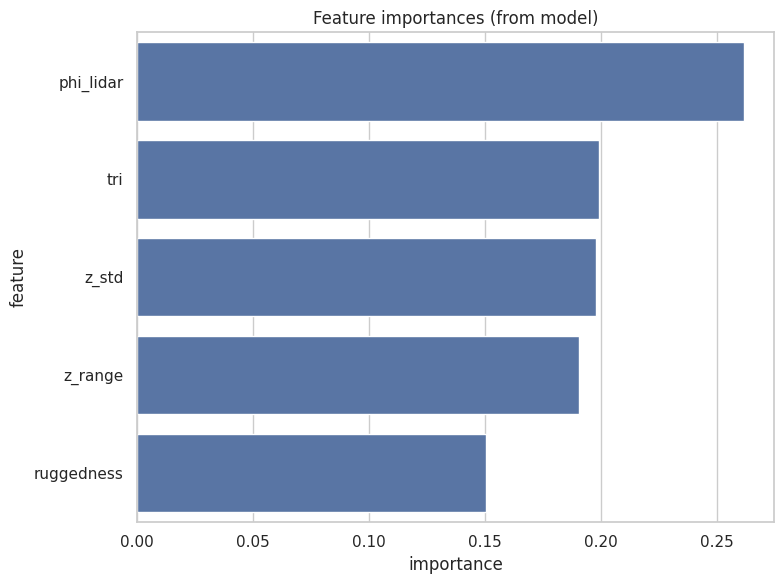

In [43]:
# 4) Importancia de features (desde el modelo si existe)
model_artifact = art.get('model')
estimator = model_artifact.get('model') if isinstance(model_artifact, dict) else model_artifact
feature_names = None

# 1) Prioridad: nombres explícitos guardados en el artefacto del modelo
if isinstance(model_artifact, dict) and model_artifact.get('feature_columns'):
    feature_names = list(model_artifact['feature_columns'])
# 2) Fallback: contexto de entrenamiento en history
elif art.get('history') and isinstance(art['history'], dict):
    tc = art['history'].get('training_context')
    if tc and 'feature_columns' in tc:
        feature_names = tc['feature_columns']

if estimator is not None:
    if hasattr(estimator, 'feature_importances_'):
        fi = np.array(estimator.feature_importances_)
        if feature_names is not None and len(feature_names) == fi.size:
            df_fi = pd.DataFrame({'feature': feature_names, 'importance': fi})
        else:
            df_fi = pd.DataFrame({'feature': [f'F{i+1}' for i in range(fi.size)], 'importance': fi})
        df_fi = df_fi.sort_values('importance', ascending=False).head(30)
        plt.figure(figsize=(8,6))
        sns.barplot(x='importance', y='feature', data=df_fi)
        plt.title('Feature importances (from model)')
        plt.tight_layout()
        plt.show()
    else:
        print('Modelo no tiene attribute feature_importances_. Intentar permutation importance si hay X_hold disponible.')
else:
    print('No se pudo cargar el modelo para extraer feature importances.')

### Qué significa esta gráfica
La importancia de features del modelo muestra qué variables usa más el estimador para construir sus decisiones.
Un valor alto indica que la variable contribuye mucho a reducir el error interno del modelo.
Si varias variables tienen importancia parecida, el problema puede estar repartido entre varias señales; si una domina, esa feature concentra gran parte de la información útil.

In [44]:
# 5) Permutation importance (requiere X_hold)
if model is not None:
    hold = try_load_holdout_df(MODEL_DIR)
    estimator = model.get('model') if isinstance(model, dict) else model
    if estimator is None and isinstance(model, dict):
        estimator = model.get('estimator') or model.get('pipeline')

    # Usar las mismas features con las que fue entrenado el modelo, si están disponibles
    if isinstance(model, dict) and model.get('feature_columns'):
        cols = [c for c in model['feature_columns'] if c in hold.columns] if hold is not None else list(model['feature_columns'])
    else:
        cols = []

    if hold is not None and 'y_true' in hold.columns:
        if not cols:
            # fallback: todas menos columnas auxiliares
            cols = [c for c in hold.columns if c not in ['y_true', 'y_pred', 'residual', 'abs_residual']]
        if cols:
            X_hold = hold[cols]
            y_hold = hold['y_true']
            try:
                if not hasattr(estimator, 'fit'):
                    raise TypeError(f'El modelo cargado no es un estimador válido: {type(estimator).__name__}')
                r = permutation_importance(estimator, X_hold, y_hold, n_repeats=10, random_state=0, n_jobs=1)
                pi = pd.DataFrame({'feature': cols, 'importance_mean': r.importances_mean})
                pi = pi.sort_values('importance_mean', ascending=False).head(30)
                plt.figure(figsize=(8,6))
                sns.barplot(x='importance_mean', y='feature', data=pi)
                plt.title('Permutation importance (holdout)')
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print('Error calculando permutation importance:', e)
        else:
            print('No se detectaron columnas de features en el holdout dataframe.')
    else:
        print('No hay holdout compatible para permutation importance. Considera guardar X_hold en próximas ejecuciones.')
else:
    print('No hay modelo para calcular permutation importance.')

NameError: name 'model' is not defined

### Qué significa esta gráfica
Permutation importance mide cuánto empeora la predicción cuando se rompe artificialmente una feature.
Si una variable provoca una caída fuerte en el desempeño al permutarse, esa variable es realmente importante para generalizar.
Es una métrica más fiable para interpretación que la importancia interna del árbol, porque se mide sobre el holdout y no solo sobre el entrenamiento.

In [45]:
# 6) Leaderboard quick view
if art.get('leaderboard') is not None:
    display(art['leaderboard'].head(20))
else:
    print('No se encontró leaderboard en la carpeta del modelo.')

,trial,optuna_trial_number,trial_state,model,params,objective_value,trial_duration_seconds,cv_r2_mean,cv_r2_std,cv_r2_min,...,cv_fold_rmses,cv_fold_maes,holdout_r2,holdout_rmse,holdout_mae,holdout_residual_mean,holdout_residual_std,holdout_abs_residual_mean,generalization_gap,is_feasible
0,8,7,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 573, 'extra_trees...",0.008812,49.137032,0.008812,0.000311,0.008367,...,"[2448.0634457751685, 2417.7338533212865, 2431....","[1285.3339753662092, 1274.3869794734064, 1282....",-0.001047,2009.319459,754.248990,-39.959792,2008.922075,754.248990,0.009859,False
1,4,3,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 841, 'extra_trees...",0.015257,78.538624,0.015257,0.000371,0.014602,...,"[2440.053359820445, 2409.7999854239238, 2423.9...","[1277.3724203445342, 1266.5128006457398, 1275....",-0.002719,2010.996316,760.666412,-38.954113,2010.618999,760.666412,0.017976,False
2,10,9,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 323, 'extra_trees...",0.122406,63.113697,0.122406,0.001425,0.120465,...,"[2301.479046991874, 2274.099888111161, 2287.37...","[1165.3847392285218, 1153.9254261357578, 1164....",-0.018583,2026.842290,788.961072,-23.675860,2026.704004,788.961072,0.140990,False
3,18,17,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 1287, 'extra_tree...",0.170937,223.764288,0.170937,0.003445,0.165261,...,"[2232.811020006508, 2212.6784812804867, 2220.9...","[1098.2461505320434, 1088.2902865228668, 1096....",-0.030207,2038.373787,808.414608,-18.528183,2038.289578,808.414608,0.201144,False
4,25,24,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 1291, 'extra_tree...",0.170895,188.029971,0.170895,0.003375,0.165554,...,"[2232.536326493709, 2213.435391123978, 2221.60...","[1095.3015162990368, 1085.529629095281, 1094.0...",-0.030855,2039.015577,807.528670,-15.936746,2038.953296,807.528670,0.201751,False
5,37,36,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 1385, 'extra_tree...",0.172472,272.142751,0.172472,0.004294,0.164595,...,"[2230.4600822314355, 2210.3754899874098, 2218....","[1094.765347403983, 1084.8580777463987, 1093.2...",-0.035089,2043.198412,813.973312,-17.653220,2043.122149,813.973312,0.207561,False
6,35,34,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 1394, 'extra_tree...",0.172877,269.024918,0.172877,0.004378,0.165086,...,"[2229.4960638455664, 2210.6608931687438, 2218....","[1092.4621877250327, 1082.7692277678836, 1090....",-0.035254,2043.361425,812.659463,-14.179595,2043.312225,812.659463,0.208131,False
7,40,39,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 1399, 'extra_tree...",0.171293,295.755516,0.171293,0.004315,0.163510,...,"[2231.869800887773, 2212.0047331286514, 2219.9...","[1096.6134626790902, 1086.6500212236213, 1095....",-0.035355,2043.460734,815.492661,-18.460331,2043.377348,815.492661,0.206648,False
8,61,60,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 927, 'extra_trees...",0.172921,198.500707,0.172921,0.004340,0.165249,...,"[2229.3459806154747, 2210.6905327376157, 2218....","[1092.0956661073033, 1082.4744245467382, 1090....",-0.035394,2043.499275,812.995058,-14.213343,2043.449845,812.995058,0.208315,False
9,34,33,COMPLETE,extra_trees,"{'extra_trees_n_estimators': 1251, 'extra_tree...",0.172836,265.788097,0.172836,0.004328,0.165140,...,"[2229.4044831954675, 2210.523130576168, 2218.6...","[1093.7021635020942, 1084.0577794773671, 1092....",-0.035689,2043.790641,814.883507,-17.069588,2043.719358,814.883507,0.208525,False


### Leyenda del Leaderboard (Parámetros e Interpretación)

A continuación se explica el significado de cada métrica reportada en el leaderboard y cómo interpretarla para elegir el mejor modelo:

*   **`objective_value`**: Es el valor numérico que el optimizador (ej. Optuna) está intentando maximizar o minimizar. Dependiendo de la configuración métrica principal (ej. R2 o RMSE negativo), un valor más alto o más bajo indicará el "mejor" modelo para el motor de búsqueda.
*   **`trial_duration_seconds`**: El tiempo en segundos que el modelo tardó en entrenar y evaluarse durante este *trial*. Útil para balancear rendimiento vs costo computacional.
*   **`cv_r2_mean`**: Promedio del $R^2$ a través de todos los *folds* de validación cruzada (CV). Indica qué tan bien generaliza el modelo de media durante el entrenamiento. Valores más cercanos a 1.0 son mejores.
*   **`cv_r2_std`**: Desviación estándar del $R^2$ entre los distintos *folds*. **Interpretación:** Un valor bajo significa que el modelo es estable y su rendimiento no depende demasiado de qué datos de entrenamiento se usaron. Un valor alto sugiere inestabilidad.
*   **`cv_r2_min`**: El peor $R^2$ obtenido en cualquiera de los *folds*. Ayuda a entender el "peor caso" de rendimiento del modelo.
*   **`cv_fold_rmses` / `cv_fold_maes`**: Listas con los errores RMSE y MAE obtenidos en cada uno de los *folds*. Permite ver el detalle del desempeño tramo a tramo.
*   **`holdout_r2`**: El $R^2$ calculado sobre el conjunto de validación o *holdout* (datos nunca vistos durante el CV). Sirve para confirmar que las métricas de CV son realistas.
*   **`holdout_rmse`**: *Root Mean Squared Error* en el holdout. Penaliza fuertemente los errores de predicción muy grandes. Menor es mejor.
*   **`holdout_mae`**: *Mean Absolute Error* en el holdout. Representa el error promedio en las mismas unidades de la variable objetivo.
*   **`holdout_residual_mean`**: Media de los residuales (Predicción - Real, o viceversa) en el holdout. Un valor cercano a 0 indica que el modelo no tiene "sesgo general". Valores positivos/negativos indican tendencia sistemática a sobreestimar/subestimar.
*   **`holdout_residual_std`**: Desviación estándar de los residuales. Indica cómo se dispersan los errores en torno a esa media. Un valor pequeño significa errores consistentes.
*   **`holdout_abs_residual_mean`**: Promedio de los residuos en valor absoluto. Matemáticamente análogo al MAE.
*   **`generalization_gap`**: Diferencia entre las métricas de validación cruzada (ej. `cv_r2_mean`) y el rendimiento en el *holdout*. **Interpretación:** Un *gap* grande advierte sobre un posible sobreajuste (overfitting) a los datos de entrenamiento/CV. Si es pequeño, el modelo generaliza bien.
*   **`is_feasible`**: Indicador booleano (True/False) que señala si el modelo cumplió con los umbrales o restricciones puestas en la búsqueda (por ejemplo, "el R2 no debe bajar de 0.5"). Sólo los verdaderos (`True`) se consideran viables.

---
Siguientes pasos recomendados:
- Re-ejecutar `adaptive_hyperparam_search.py` añadiendo persistencia de `holdout_predictions.csv` para análisis reproducible.
- Ajustar `MODEL_DIR` arriba y ejecutar cada celda secuencialmente.